In [1]:
import os
from pathlib import Path

print("CWD =", os.getcwd())
print("Has data/?", Path("data").exists())
print("Top-level:", [p.name for p in Path(".").iterdir()][:20])

CWD = /Users/gaohan/Finance-Research
Has data/? True
Top-level: ['README.md', '.git', 'data']


In [3]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data")

# 你可以按你项目实际再加更多日期列候选名
DATE_CANDIDATES = ["date", "Date", "datetime", "timestamp", "DATE"]

def infer_date_col(df: pd.DataFrame):
    for c in DATE_CANDIDATES:
        if c in df.columns:
            return c
    # 兜底：找列名里包含 date 的
    for c in df.columns:
        if "date" in c.lower():
            return c
    return None

def summarize_one_file(folder: Path):
    # 优先选 csv；如果没有 csv 再选 json
    csvs = sorted(folder.glob("*.csv"))
    if csvs:
        fp = csvs[0]  # 每个 folder 取第一个文件当 sample（你也可以改成随机）
        df = pd.read_csv(fp)
        date_col = infer_date_col(df)
        if date_col:
            d = pd.to_datetime(df[date_col], errors="coerce")
            date_min = d.min()
            date_max = d.max()
        else:
            date_min = None
            date_max = None

        return {
            "folder": str(folder.relative_to(DATA_DIR)),
            "sample_file": fp.name,
            "date_col": date_col,
            "date_min": date_min,
            "date_max": date_max,
            "columns": list(df.columns),
        }

    jsons = sorted(folder.glob("*.json"))
    if jsons:
        fp = jsons[0]
        # JSON 这里不强行解析成表；只给你文件名（macro.json 你如果要也可以我再加）
        return {
            "folder": str(folder.relative_to(DATA_DIR)),
            "sample_file": fp.name,
            "date_col": None,
            "date_min": None,
            "date_max": None,
            "columns": None,
            "note": "JSON file (not tabular); open separately if needed.",
        }

    return {
        "folder": str(folder.relative_to(DATA_DIR)),
        "sample_file": None,
        "note": "No files found in this folder.",
    }

rows = []
for folder in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    rows.append(summarize_one_file(folder))

summary = pd.DataFrame(rows)

# 让 columns 更好读
summary_display = summary.copy()
summary_display["columns"] = summary_display["columns"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) else x
)

summary_display

,folder,sample_file,date_col,date_min,date_max,columns
0,company_dataset,AAPL.csv,date,2022-01-03,2024-12-31,"date, open, high, low, close, adjusted_close, ..."
1,fundamentals_csv,AAPL.csv,date,2022-03-31,2024-12-31,"date, symbol, revenue, net_income, eps, operat..."
2,macro,macro.csv,date,2022-01-01,2024-12-31,"date, real_gdp, real_gdp_per_capita, cpi, infl..."
3,prices,AAPL.csv,date,2022-01-03,2024-12-31,"date, open, high, low, close, adjusted_close, ..."
4,processed_company_dataset,AAPL.csv,date,2021-07-03,2024-12-31,"date, symbol, log_ret, volatility_20d, volume_..."


In [4]:
import pandas as pd

# 让 dataframe 显示不截断
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 2000)

# summary_display 是你上个 cell 得到的 DataFrame
display(summary_display)

,folder,sample_file,date_col,date_min,date_max,columns
0,company_dataset,AAPL.csv,date,2022-01-03,2024-12-31,"date, open, high, low, close, adjusted_close, volume, dividend_amount, split_coefficient, symbol, revenue, net_income, operating_income, gross_profit, total_assets, total_liabilities, long_term_debt, cash_and_equivalents, operating_cashflow, capital_expenditures, real_gdp, real_gdp_per_capita, cpi, inflation, unemployment, federal_funds_rate, retail_sales, treasury_yield_10y"
1,fundamentals_csv,AAPL.csv,date,2022-03-31,2024-12-31,"date, symbol, revenue, net_income, eps, operating_income, gross_profit, total_assets, total_liabilities, long_term_debt, cash_and_equivalents, operating_cashflow, capital_expenditures"
2,macro,macro.csv,date,2022-01-01,2024-12-31,"date, real_gdp, real_gdp_per_capita, cpi, inflation, unemployment, federal_funds_rate, retail_sales, treasury_yield_10y"
3,prices,AAPL.csv,date,2022-01-03,2024-12-31,"date, open, high, low, close, adjusted_close, volume, dividend_amount, split_coefficient"
4,processed_company_dataset,AAPL.csv,date,2021-07-03,2024-12-31,"date, symbol, log_ret, volatility_20d, volume_change, ps_ratio, pe_ratio, rev_growth_qoq, real_rate, yield_curve, unemployment_change, close, is_trading_day"


In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

PRICE_DIR = Path("data/prices")
files = sorted(PRICE_DIR.glob("*.csv"))
assert files, f"No price files found in {PRICE_DIR.resolve()}"

dfs = []
for fp in files:
    df = pd.read_csv(fp)
    df["date"] = pd.to_datetime(df["date"])
    # 用 adjusted_close 做回测更合理
    df = df.rename(columns={"adjusted_close": "close_adj"})
    df["tic"] = fp.stem  # AAPL.csv -> AAPL
    dfs.append(df[["date","tic","close_adj"]])

daily = pd.concat(dfs, ignore_index=True).sort_values(["tic","date"])
px = daily.pivot(index="date", columns="tic", values="close_adj").sort_index()

# close-to-close returns
ret_df = px.pct_change().sort_index()

px.tail(), ret_df.tail()


(tic               AAPL     AMD        ASML        AVGO       GOOGL        MSFT        NVDA        QCOM         TSM         TXN
 date                                                                                                                          
 2024-12-24  257.056489  126.29  709.902488  237.963126  195.465120  436.934606  140.190157  156.673308  204.167845  186.371788
 2024-12-26  257.872857  125.06  706.104953  243.602440  194.956797  435.721257  139.900219  155.857301  200.932111  185.684177
 2024-12-27  254.458048  125.19  703.865886  240.018299  192.126136  428.182587  136.980841  154.589050  199.517097  185.151520
 2024-12-30  251.083061  122.44  686.663541  233.892496  190.611134  422.513665  137.460738  151.973895  198.290091  182.033056
 2024-12-31  249.310945  120.79  683.635376  230.179286  188.677513  419.201822  134.261420  151.030080  195.420480  181.597246,
 tic             AAPL       AMD      ASML      AVGO     GOOGL      MSFT      NVDA      QCOM       TSM  

In [11]:
# 月初调仓日：每月第一个可交易日（在 px.index 里存在的日期）
reb_dates = (
    pd.Series(px.index, index=px.index)
    .groupby(px.index.to_period("M"))
    .min()
    .sort_values()
)

reb_dates.head(), reb_dates.tail()

(date
 2022-01   2022-01-03
 2022-02   2022-02-01
 2022-03   2022-03-01
 2022-04   2022-04-01
 2022-05   2022-05-02
 Freq: M, Name: date, dtype: datetime64[ns],
 date
 2024-08   2024-08-01
 2024-09   2024-09-03
 2024-10   2024-10-01
 2024-11   2024-11-01
 2024-12   2024-12-02
 Freq: M, Name: date, dtype: datetime64[ns])

In [12]:
TOPN = 3
MOM_WINDOW = 63       # ~3个月
VOL_WINDOW = 20       # 20日波动（你也可以用60）
WEIGHT_CAP = 0.7      # 小 universe 要把 cap 放大，不然会很怪

mom = px.pct_change(MOM_WINDOW)
vol = ret_df.rolling(VOL_WINDOW).std() * np.sqrt(252)

all_tics = list(px.columns)

weights = {}
for d in reb_dates:
    if d not in mom.index or d not in vol.index:
        continue
    
    mom_d = mom.loc[d].dropna()
    vol_d = vol.loc[d].replace(0, np.nan).dropna()
    common = mom_d.index.intersection(vol_d.index)
    if len(common) < 3:
        continue
    
    # 只做正动量过滤（可选）
    mom_rank = mom_d.loc[common].sort_values(ascending=False)
    picked = mom_rank.head(min(TOPN, len(mom_rank))).index.tolist()
    if len(picked) == 0:
        continue
    
    v = vol_d.loc[picked].dropna()
    picked = v.index.tolist()
    if len(picked) == 0:
        continue
    
    w = (1.0 / v)
    w = w / w.sum()
    w = w.clip(upper=WEIGHT_CAP)
    w = w / w.sum()

    row = {tic: 0.0 for tic in all_tics}
    for tic, val in w.items():
        row[tic] = float(val)
    weights[pd.Timestamp(d)] = row

W = pd.DataFrame(weights).T.sort_index()
W.index.name = "date"

W.head()

,AAPL,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,QCOM,TSM,TXN
date,,,,,,,,,,
2022-05-02,0.000000,0.000000,0.0,0.311341,0.0,0.288066,0.0,0.000000,0.0,0.400593
2022-06-01,0.000000,0.000000,0.0,0.251037,0.0,0.338821,0.0,0.000000,0.0,0.410141
2022-07-01,0.000000,0.000000,0.0,0.000000,0.0,0.323292,0.0,0.269041,0.0,0.407667
2022-08-01,0.000000,0.295772,0.0,0.000000,0.0,0.000000,0.0,0.299025,0.0,0.405204
2022-09-01,0.355059,0.000000,0.0,0.000000,0.0,0.375046,0.0,0.000000,0.0,0.269895


In [13]:
def backtest_weights_returns(portfolio_weights_df, ret_df, fee_rate=0.0005, lag_weights=1):
    """
    portfolio_weights_df: index=date (rebalance days), columns=tickers, values=weights (sum<=1)
    ret_df: index=date (daily), columns=tickers, values=daily simple returns
    fee_rate: 单边手续费（很粗略）
    lag_weights: 1 表示权重从下一交易日生效（关键）
    """
    # 对齐日期
    trade_index = ret_df.index
    
    # 把调仓权重扩展到每日：ffill
    W_daily = portfolio_weights_df.reindex(trade_index).ffill().fillna(0.0)

    # 权重滞后：避免 look-ahead
    W_exec = W_daily.shift(lag_weights).fillna(0.0)

    # 组合收益（未投资部分视为现金=0收益）
    port_ret_gross = (W_exec * ret_df.fillna(0.0)).sum(axis=1)

    # 手续费：用 turnover * fee_rate（近似）
    turnover = W_exec.diff().abs().sum(axis=1).fillna(0.0)
    port_ret_net = port_ret_gross - fee_rate * turnover

    nav = (1 + port_ret_net).cumprod()
    out = pd.DataFrame({
        "gross_ret": port_ret_gross,
        "net_ret": port_ret_net,
        "turnover": turnover,
        "nav": nav / nav.iloc[0]
    })
    return out, W_exec

result, W_exec = backtest_weights_returns(W, ret_df, fee_rate=0.0005, lag_weights=1)
result.tail()

,gross_ret,net_ret,turnover,nav
date,,,,
2024-12-24,0.011278,0.011278,0.0,2.702461
2024-12-26,0.002993,0.002993,0.0,2.710549
2024-12-27,-0.014060,-0.014060,0.0,2.672439
2024-12-30,-0.010433,-0.010433,0.0,2.644557
2024-12-31,-0.017648,-0.017648,0.0,2.597888


In [15]:
import numpy as np
import pandas as pd

TARGET_VOL = 0.20   # 目标年化波动 20%
VOL_LOOKBACK = 20

# 用组合净收益估计滚动波动
roll_vol = result["net_ret"].rolling(VOL_LOOKBACK).std(ddof=0) * np.sqrt(252)
scale = (TARGET_VOL / (roll_vol + 1e-12)).clip(upper=1.5)  # 可限制最大杠杆，比如 1.5
scale = scale.fillna(0.0)

vt_ret = result["net_ret"] * scale
vt_nav = (1 + vt_ret).cumprod()
vt_nav = vt_nav / vt_nav.iloc[0]

def perf_from_ret(daily_ret):
    nav = (1 + daily_ret).cumprod()
    nav = nav / nav.iloc[0]
    ann_ret = nav.iloc[-1] ** (252/len(nav)) - 1
    ann_vol = daily_ret.std(ddof=0) * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-12)
    dd = nav / nav.cummax() - 1
    return ann_ret, ann_vol, sharpe, dd.min()

ann_ret, ann_vol, sharpe, max_dd = perf_from_ret(vt_ret.fillna(0.0))
print(f"Vol-Targeted AnnRet={ann_ret:.2%}, AnnVol={ann_vol:.2%}, Sharpe={sharpe:.2f}, MaxDD={max_dd:.2%}")

Vol-Targeted AnnRet=23.01%, AnnVol=19.90%, Sharpe=1.16, MaxDD=-15.97%


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def perf_table(returns: pd.DataFrame, freq=252) -> pd.DataFrame:
    """
    returns: DataFrame, index=date, columns=strategy/ticker names, values=daily simple returns
    """
    r = returns.copy().fillna(0.0)
    nav = (1 + r).cumprod()

    ann_ret = nav.iloc[-1] ** (freq / len(nav)) - 1
    ann_vol = r.std(ddof=0) * np.sqrt(freq)
    sharpe = ann_ret / (ann_vol + 1e-12)

    dd = nav.div(nav.cummax()) - 1
    max_dd = dd.min()

    out = pd.DataFrame({
        "Annual Return": ann_ret,
        "Annual Volatility": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    })

    return out

def plot_equity_curves(returns: pd.DataFrame, title="Equity Curves (Cumulative Return)"):
    r = returns.copy().fillna(0.0)
    nav = (1 + r).cumprod()
    nav = nav / nav.iloc[0]

    plt.figure(figsize=(10,4))
    plt.plot(nav.index, nav.values)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.grid(True)
    plt.legend(nav.columns, loc="upper left")
    plt.show()

    return nav

In [18]:
# 1) 策略日收益
strategy_ret = result["net_ret"].rename("Strategy")

# 2) Vol-targeted 日收益（你之前算过 vt_ret）
vt_strategy_ret = vt_ret.rename("Strategy (Vol-Targeted)")

# 3) 基准：10只股票等权
ew_ret = ret_df.mean(axis=1).fillna(0.0).rename("Benchmark (Equal-Weight 10)")

returns_to_compare = pd.concat([strategy_ret, vt_strategy_ret, ew_ret], axis=1).dropna()
returns_to_compare.head()

,Strategy,Strategy (Vol-Targeted),Benchmark (Equal-Weight 10)
date,,,
2022-01-03,0.0,0.0,0.000000
2022-01-04,0.0,0.0,-0.006950
2022-01-05,0.0,0.0,-0.038261
2022-01-06,0.0,0.0,0.001853
2022-01-07,0.0,0.0,-0.021284


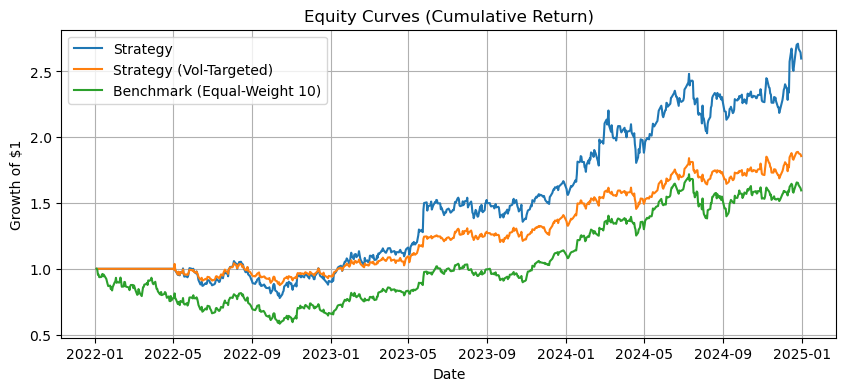

,Annual Return,Annual Volatility,Sharpe,Max Drawdown
Strategy,0.376440,0.317083,1.187198,-0.265281
Strategy (Vol-Targeted),0.230070,0.198951,1.156412,-0.159724
Benchmark (Equal-Weight 10),0.169332,0.310504,0.545346,-0.417353


In [21]:
nav = plot_equity_curves(returns_to_compare)

table = perf_table(returns_to_compare)
table

In [20]:
# 显示为百分比（可选）
table_style = table.copy()
table_style["Annual Return"] = table_style["Annual Return"].map(lambda x: f"{x:.2%}")
table_style["Annual Volatility"] = table_style["Annual Volatility"].map(lambda x: f"{x:.2%}")
table_style["Sharpe"] = table_style["Sharpe"].map(lambda x: f"{x:.2f}")
table_style["Max Drawdown"] = table_style["Max Drawdown"].map(lambda x: f"{x:.2%}")

table_style

,Annual Return,Annual Volatility,Sharpe,Max Drawdown
Strategy,37.64%,31.71%,1.19,-26.53%
Strategy (Vol-Targeted),23.01%,19.90%,1.16,-15.97%
Benchmark (Equal-Weight 10),16.93%,31.05%,0.55,-41.74%


In [29]:
import yfinance as yf
import pandas as pd

start = returns_to_compare.index.min().strftime("%Y-%m-%d")
end   = returns_to_compare.index.max().strftime("%Y-%m-%d")

spy = yf.download("SPY", start=start, end=end, auto_adjust=True, progress=False)

# 兼容 MultiIndex columns / 不同版本 yfinance
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy = spy.rename(columns=lambda c: str(c).lower())

spy_ret = spy["close"].pct_change().rename("SPY (S&P 500)")
spy_ret.head()

Date
2022-01-03         NaN
2022-01-04   -0.000335
2022-01-05   -0.019202
2022-01-06   -0.000939
2022-01-07   -0.003954
Name: SPY (S&P 500), dtype: float64

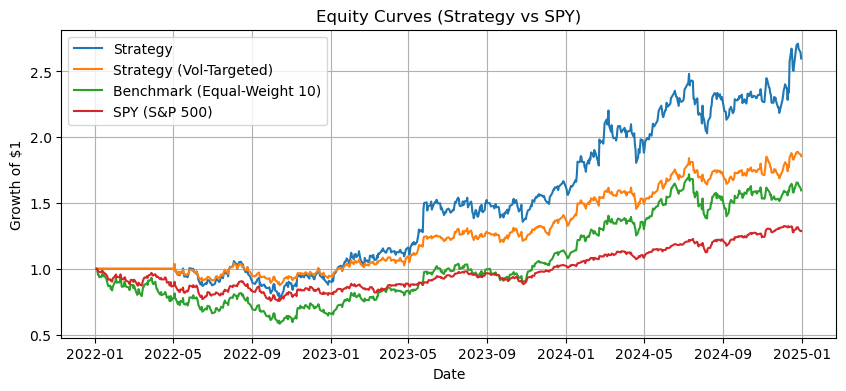

In [30]:
import matplotlib.pyplot as plt

# 合并
returns_cmp = pd.concat([returns_to_compare, spy_ret], axis=1)

# 这里我建议用 fillna(0) 而不是 dropna，避免因日期不完全重合导致全删
returns_cmp = returns_cmp.fillna(0.0)

# 画净值
nav = (1 + returns_cmp).cumprod()
nav = nav / nav.iloc[0]

plt.figure(figsize=(10,4))
plt.plot(nav.index, nav.values)
plt.title("Equity Curves (Strategy vs SPY)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.legend(nav.columns, loc="upper left")
plt.show()